# Atividade 1 -- Tópicos para Computação 1 -- 2026.1

- Escola Superior de Tecnologia
- Profa. Dra. Elloá B. Guedes (ebgcosta@uea.edu.br)
- www.elloaguedes.com
- github.com/elloa
- Data: 03 de março de 2026

## Descrição

A atividade consiste em usar um extrator de bordas clássico, o filtro Sobel, em duas imagens, visualizando o resultado e construindo o mapa/vetor de características resultante dessa extração. Visa ilustrar o processo manual e as operações matemáticas envolvidas em algoritmos extratores de características tradicionais, bem como introduzir competências técnicas e tecnológicas para realização de operações como a convolução em ambiente computacional.

## Prazos importantes

- Data de entrega: 09/03/2026
- Modo de entrega: Google Classroom
- Estratégia de desenvolvimento: Duplas


In [109]:
## Espaço para importar bibliotecas

import cv2
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import Tensor
from torch.nn import functional


### Abrir imagem

Utilizando o pacote opencv (cv2) e a função imread, abra uma imagem de sua preferência. A imagem deve ser aberta em tons de cinza Como exemplo, há as imagens 'badbunny' e 'deepfake'. Em seguida, visualize a imagem após a abertura.

In [110]:
img_severance = cv2.imread("severance_group.jpg", cv2.IMREAD_GRAYSCALE)

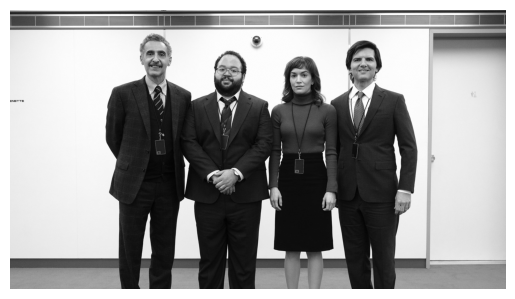

In [111]:
plt.imshow(img_severance, cmap="gray")
plt.axis("off")
plt.show()


## Conversão da imagem

Para que a imagem possa ser processada com o Pytorch, ela precisa ser um tensor de 4 dimensões.

Esse tensor possui a seguinte estrutura [B, C, H, W], em que:
- Batch: denota quantas imagens estão sendo processadas de uma vez (B = 1).
- Channel: denota quantos canais de cor (C = 1 para Cinza, C = 3 para RGB).
- Height: altura da imagem em pixels.
- Width: largura da imagem em pixels.

Use o comando:

img_tensor = torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0)

1. torch.from_numpy(img): Converte a matriz do NumPy do Opencv em um tensor do PyTorch
2. float(): converte de uint8 para float
3. unsqueeze(0): adiciona 1 dimensão, i.e., [1, H, W]
4. unsqueeze(0): adiciona outra dimensão, i.e., [1, 1, H, W]

Ao final, temos o tensor desejado.   
Imprima o tipo e sua forma (shape)  
Verifique as dimensões da imagem  

In [112]:
img_tensor: Tensor = torch.from_numpy(img_severance).float().unsqueeze(0).unsqueeze(0)

In [113]:
img_tensor: Tensor = img_tensor / 255.0 #normalização de escala de cinza para [0, 1]

In [114]:
print(f"Class: {type(img_tensor)}")
print(f"Shape: {img_tensor.shape}")

Class: <class 'torch.Tensor'>
Shape: torch.Size([1, 1, 1080, 1920])


## Filtro Sobel

O filtro Sobel é uma operação utilizada em processamento de imagem, aplicada sobretudo em algoritmos de detecção de contornos. Ele calcula o gradiente da intensidade da imagem em cada ponto, dando a direcção da maior variação de claro para escuro e a quantidade de variação nessa direcção. Assim, obtém-se uma noção de como varia a luminosidade em cada ponto, de forma mais suave ou abrupta. Com isto consegue-se estimar a presença de uma transição claro-escuro e de qual a orientação desta. Como as variações claro-escuro intensas correspondem a fronteiras bem definidas entre objectos, consegue-se fazer a detecção de contornos.

O Filtro Sobel utiliza duas matrizes $3 \times 3$ que são convoluídas com a imagem original $A$ para calcular a magnitude e a direção do gradiente, da seguinte forma:


$$
\mathbf{G_x} = \begin{bmatrix} 
-1 & 0 & +1 \\ 
-2 & 0 & +2 \\ 
-1 & 0 & +1 
\end{bmatrix} * \mathbf{A} 
\quad \text{e} \quad 
\mathbf{G_y} = \begin{bmatrix} 
+1 & +2 & +1 \\ 
0 & 0 & 0 \\ 
-1 & -2 & -1 
\end{bmatrix} * \mathbf{A}
$$

Portanto a magnitude, $\mathbf{G}$, e a direcção, $\mathbf{\Theta}$, do gradiente são dados por:

$$
\begin{aligned}
\mathbf{G} &= \sqrt{\mathbf{G_x}^2 + \mathbf{G_y}^2} \\
\mathbf{\Theta} &= \arctan\left(\frac{\mathbf{G_y}}{\mathbf{G_x}}\right)
\end{aligned}
$$


### Definição dos tensores para as matrizes do Filtro Sobel

Para proceder com a aplicação do Filtro Sobel, crie dois tensores (1,1,3,3) com as matrizes $K_x$ e $K_y$ dadas a seguir:

$$
K_x = \begin{bmatrix} 
-1 & 0 & 1 \\ 
-2 & 0 & 2 \\ 
-1 & 0 & 1 
\end{bmatrix}
$$

$$K_y = \begin{bmatrix} 
+1 & +2 & +1 \\ 
0 & 0 & 0 \\ 
-1 & -2 & -1 
\end{bmatrix}
$$

In [115]:
kx: Tensor = torch.tensor([
    [-1,  0,  1],
    [-2,  0,  2],
    [-1,  0,  1],
], dtype=torch.float32).unsqueeze(0).unsqueeze(0)

ky: Tensor = torch.tensor([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1],
], dtype=torch.float32).unsqueeze(0).unsqueeze(0)

print(kx.shape)
print(ky.shape)

torch.Size([1, 1, 3, 3])
torch.Size([1, 1, 3, 3])


### Entendendo a Convolução

No contexto de processamento de imagens e visão computacional, a convolução é uma operação matemática em que uma pequena matriz, chamada filtro ou kernel é "deslizada" sobre a imagem original para extrair características específicas.

- Kernel (Filtro): É uma matriz pequena (como o $G_x$ e $G_y$ no filtro Sobel) que contém pesos matemáticos definidos para detectar padrões
- Operação de convolução: Em cada posição da imagem, o kernel é sobreposto aos pixels da imagem. Multiplica-se cada peso do kernel pelo valor do pixel correspondente e somam-se todos esses resultados.
- Mapa de Características: O resultado dessa soma torna-se um único pixel na nova imagem (o "feature map"). Esse novo valor indica a presença ou a força da característica naquele local exato.

#### Exercício de Convolução Manual

Considere a matriz da imagem $\mathbf{M}$ e o filtro $\mathbf{F}$ a seguir:

$$
\mathbf{M} = \begin{bmatrix} 
10 & 10 & 0 & 0 \\ 
10 & 10 & 0 & 0 \\ 
10 & 10 & 0 & 0 \\ 
10 & 10 & 0 & 0 
\end{bmatrix}
\quad , \quad
\mathbf{F} = \begin{bmatrix} 
-1 & 0 & 1 \\ 
-1 & 0 & 1 \\ 
-1 & 0 & 1 
\end{bmatrix}
$$

**Tarefa:**
Calcule o mapa de características resultante da convolução $(F * M)$. 

**Equação Auxiliar:**
$$y[i, j] = \sum_{m} \sum_{n} \mathbf{M}[i-m, j-n] \cdot \mathbf{F}[m, n]$$

In [116]:
M_die = np.array([
    [10, 10,  0,  0],
    [10, 10,  0,  0],
    [10, 10,  0,  0],
    [10, 10,  0,  0],
])

F_die = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1],
])

H, W = M_die.shape
kH, kW = F_die.shape

out_H = H - kH + 1
out_W = W - kW + 1

output = np.zeros((out_H, out_W))

for i in range(out_H):
    for j in range(out_W):
        region = M_die[i:i+kH, j:j+kW]
        output[i, j] = np.sum(region * F_die)

output

array([[-30., -30.],
       [-30., -30.]])

#### Convolução no Pytorch

Utilize  
import torch.nn.functional as F  

e faça   
gx = F.conv2d(img_tensor, kx, padding=1)

Repita o mesmo para obter gy  

In [117]:
gx: Tensor = functional.conv2d(img_tensor, kx, padding=1)
gy: Tensor = functional.conv2d(img_tensor, ky, padding=1)

### Magnitude do Gradiente

Calcule a magnitude do gradiente, dada como segue:

$$
\mathbf{G} = \sqrt{\mathbf{G_x}^2 + \mathbf{G_y}^2}
$$ 

Use a função torch.sqrt

In [118]:
G: Tensor = torch.sqrt(gx**2 + gy**2)
print(G.shape)
print(G)

torch.Size([1, 1, 1080, 1920])
tensor([[[[3.2236, 3.1139, 3.1137,  ..., 1.0551, 1.0237, 1.1694],
          [3.0251, 0.1477, 0.1741,  ..., 0.5974, 0.6349, 1.1154],
          [3.0627, 0.0166, 0.0422,  ..., 0.6052, 0.5945, 0.8193],
          ...,
          [2.3978, 0.1166, 0.0323,  ..., 0.0632, 0.1493, 2.3417],
          [2.3985, 0.1831, 0.0571,  ..., 0.1138, 0.1612, 2.3343],
          [2.5357, 2.4363, 2.3686,  ..., 2.3726, 2.3464, 2.4347]]]])


### Orientação do gradiente

A orientação do  gradiente é dada por:

$$\mathbf{\Theta} = \arctan\left(\frac{\mathbf{G_y}}{\mathbf{G_x}}\right)$$

Use a função torch.atan2 e converta para graus, multiplicando por $180/\pi$
- Para $\pi$, use a constante do numpy

In [119]:
# .atan2 calcula o arco tangente elemento a elemento de dois tensores, input = y, other = x
theta: Tensor = torch.atan2(gy, gx) * (180 / np.pi)
theta

tensor([[[[-4.6676e+01, -9.0577e+01, -9.0000e+01,  ..., -9.1065e+01,
           -9.1097e+01, -1.4017e+02],
          [-1.8572e+00, -1.0071e+02, -8.2235e+01,  ...,  9.3764e+01,
            9.6028e+01,  1.5325e+02],
          [-7.3363e-02, -1.3500e+02, -2.1802e+01,  ...,  9.3715e+01,
            9.8344e+01,  1.4791e+02],
          ...,
          [-3.9387e+00, -1.0965e+02,  1.6596e+02,  ..., -9.7125e+01,
           -1.5007e+02, -1.7875e+02],
          [ 7.0437e+00,  8.0134e+01,  1.6405e+02,  ...,  8.8025e+01,
            1.3895e+02,  1.7836e+02],
          [ 4.6755e+01,  8.5106e+01,  9.0190e+01,  ...,  9.0095e+01,
            9.1916e+01,  1.3487e+02]]]])

### Visualização do Resultado

- Para visualizar, converta os tensores para array numpy 2D. 
- Normalize a magnitude para o intervalo $[0,255]$
- Utilize o espaço de cores hsv para mostrar a orientação do gradiente
- Exiba os resultados da magnitude e da orientação ao lado da imagem original, de forma comparativa

In [120]:
# .squeeze remove dimensão tamanho 1 do tensor
# .numpy transforma o tensor em array
G_np    = G.squeeze().numpy()
theta_np = theta.squeeze().numpy()

In [121]:
G_np

array([[3.2235675 , 3.1138837 , 3.1137254 , ..., 1.0550842 , 1.0237173 ,
        1.1694037 ],
       [3.0251188 , 0.14767185, 0.17414565, ..., 0.597367  , 0.6348825 ,
        1.1154089 ],
       [3.0627475 , 0.01663768, 0.04223663, ..., 0.6051936 , 0.5945286 ,
        0.819317  ],
       ...,
       [2.3978207 , 0.11659682, 0.03233805, ..., 0.06323346, 0.1493288 ,
        2.3417313 ],
       [2.3984938 , 0.18309999, 0.05709884, ..., 0.1137932 , 0.16121417,
        2.3342857 ],
       [2.5356817 , 2.4363327 , 2.3686404 , ..., 2.3725524 , 2.3464093 ,
        2.434672  ]], shape=(1080, 1920), dtype=float32)

In [122]:
theta_np

array([[-4.66759911e+01, -9.05772705e+01, -9.00000000e+01, ...,
        -9.10648575e+01, -9.10974884e+01, -1.40169830e+02],
       [-1.85718882e+00, -1.00713104e+02, -8.22348404e+01, ...,
         9.37640381e+01,  9.60275345e+01,  1.53254776e+02],
       [-7.33631402e-02, -1.35000443e+02, -2.18015594e+01, ...,
         9.37152863e+01,  9.83438950e+01,  1.47907410e+02],
       ...,
       [-3.93873835e+00, -1.09653755e+02,  1.65963974e+02, ...,
        -9.71250687e+01, -1.50068497e+02, -1.78752548e+02],
       [ 7.04368067e+00,  8.01342010e+01,  1.64054596e+02, ...,
         8.80250702e+01,  1.38945145e+02,  1.78363419e+02],
       [ 4.67546844e+01,  8.51061630e+01,  9.01897202e+01, ...,
         9.00947037e+01,  9.19155350e+01,  1.34869492e+02]],
      shape=(1080, 1920), dtype=float32)

In [ ]:
# Mapeia o intervalo de valores da array de intervalo (0, 1) para (0, 255) então 0 = 0, 1 = 255 e os valores no meio são convertidos proporcionalmente
G_norm = (G_np - G_np.min()) / (G_np.max() - G_np.min()) * 255
# g_np - g_np.min basicamente pega o menor valor e transforma ele em 0
# array [1.0, 2.0, 3.0] o mínimo é 1.0 então ele faz a subtração elemento por elemento do valor - mínimo
# Então nesse caso ficaria [0.0, 1.0, 2.0]

# Depois divide elemento por elemento pelo máximo - mínimo que no exemplo seria 2.0
# O resultado disso fica o intervalo de 0.0 a 1.0
# No final, basta multiplicar por 255 para chegarmos no que foi explicado na primeira linha dessa célula
G_norm = G_norm.astype(np.uint8) # converte float para int
G_norm

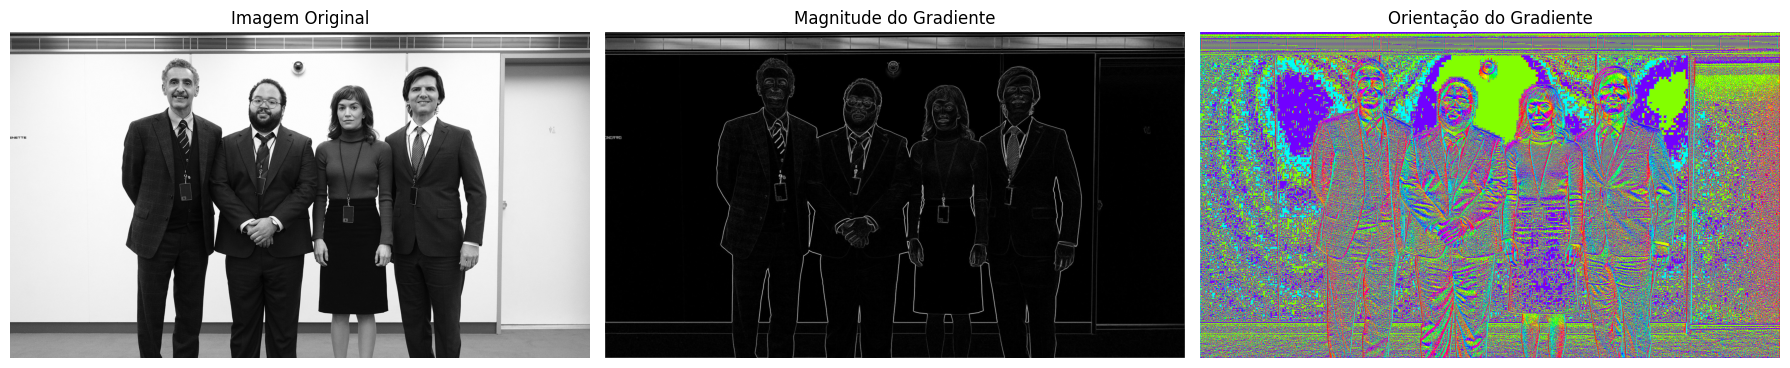

In [124]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_severance, cmap="gray")
axes[0].set_title("Imagem Original")
axes[0].axis("off")

axes[1].imshow(G_norm, cmap="gray")
axes[1].set_title("Magnitude do Gradiente")
axes[1].axis("off")

axes[2].imshow(theta_np, cmap="hsv")
axes[2].set_title("Orientação do Gradiente")
axes[2].axis("off")

plt.tight_layout()
plt.show()

O plot de orientação do gradiente ficou muito estranho\
Pesquisando, descobrimos que internamente o matplotlib faz o mapeamento da imagem hsv para rgb\
Mas aparentemente não faz muito bem\
Então faremos "manualmente" para visualizar o resultado

In [ ]:
# theta está em [-180, 180], normaliza para [0, 1]
H_channel = (theta_np + 180) / 360.0

# saturação máxima
S_channel = np.ones_like(H_channel)

# magnitude normalizada [0, 1] como brilho
V_channel = G_np / G_np.max()

# empilha os 3 canais
hsv_img = np.stack([H_channel, S_channel, V_channel], axis=-1)

# transforma para rgb
rgb_img = mcolors.hsv_to_rgb(hsv_img)

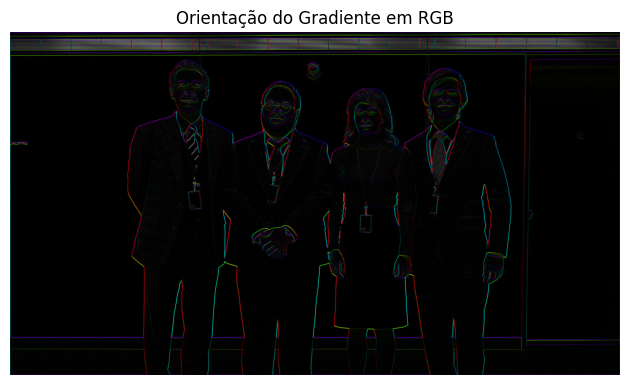

In [126]:
plt.imshow(rgb_img)
plt.title("Orientação do Gradiente em RGB")
plt.axis("off")
plt.tight_layout()

## Construa o vetor de características de Sobel

Observe que temos quatro matrizes além da imagem original (são elas, Gx, Gy, G e Theta). Observe que temos muito mais informação do que inicialmente começamos. Precisamos de um vetor de características global, que captura a essência das características da imagem:

### Flatten

Para obter um vetor (1D), precisamos "planificar" a matriz (2D):  
feat_magnitude = g.cpu().numpy().flatten()

### Dados Estatísticos

O vetor de características será obtido a partir de dados estatísticos da magnitude:
1. Calcule a média da magnitude: Indica a "quantidade" geral de bordas, de tal modo que uma imagem com muitas linhas terá uma média alta.
2. Calcule o desvio padrão da magnitude: Indica o contraste das bordas, isto é, diz se as bordas são todas parecidas ou se há grandes variações de intensidade.
3. Máximo: Identifica a borda mais forte encontrada na imagem.

### Concatenação

Concatene os vetores resultantes (magnitude e dados estatísticos), produzindo uma espécie de resumo das características da imagem avaliadas por Sobel

In [127]:
feat_magnitude = G.cpu().numpy().flatten()
feat_magnitude

array([3.2235675, 3.1138837, 3.1137254, ..., 2.3725524, 2.3464093,
       2.434672 ], shape=(2073600,), dtype=float32)

In [128]:
media  = np.mean(feat_magnitude)
desvio = np.std(feat_magnitude)
maximo = np.max(feat_magnitude)

print(f"Média: {media:.4f}")
print(f"Desvio Padrão: {desvio:.4f}")
print(f"Máximo: {maximo:.4f}")

Média: 0.2018
Desvio Padrão: 0.5572
Máximo: 4.2667


In [129]:
# np.array agrupa os 3 escalares em um vetor de tamanho 3
stats = np.array([media, desvio, maximo])

# np.concatenate junta o vetor de pixels com o vetor de estatísticas
feat_vector = np.concatenate([feat_magnitude, stats])

### Argumente

O vetor de características resultante possui maior dimensão do que a imagem original, além de ter demandado processamento para ser obtido. Como ele pode ser útil em um contexto prático em uma tarefa de Visão Computacional? O esforço realizado vale a pena?

A imagem original só tem informações sobre intensidade de pixels, o filtro Sobel transforma esses pixels em características que o modelo vai interpretar melhor. O vetor de características Sobel informa onde estão as bordas, qual a intensidade e qual a direção, informações muito mais importantes e significativas para um modelo identificar padrões.

Vale a pena?\
Sim, apesar de demandar tempo de processamento e resultar em um vetor de dimensão muito maior, o filtro Sobel é essencial para que modelos possam extrair características, o que resulta em um aprendizado significativamente mais eficiente e com maior acurácia.